In [1]:
import matplotlib.pyplot as plt

from link_prediction.config import (
    RESULTS_DIR,
    load_experiment_config,
    load_methods_config,
)
from link_prediction.statistical_analysis import (
    load_benchmark_fold_metrics,
    run_confirmatory_analysis,
)

In [2]:
benchmark_name = "standard"

experiment_config = (
    load_experiment_config()
)

methods_config = (
    load_methods_config()
)

statistics_config = (
    experiment_config[
        "statistics"
    ]
)

method_ids = list(
    statistics_config[
        "confirmatory_methods"
    ]
)

metrics = tuple(
    statistics_config[
        "metrics"
    ]
)

alpha = float(
    statistics_config[
        "alpha"
    ]
)

method_names = {
    method_id:
        methods_config[
            "methods"
        ][
            method_id
        ][
            "name"
        ]
    for method_id in method_ids
}

figure_directory = (
    RESULTS_DIR
    / "figures"
    / benchmark_name
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True,
)

fold_metrics = (
    load_benchmark_fold_metrics(
        benchmark_name=
            benchmark_name,
    )
)

statistical_results = (
    run_confirmatory_analysis(
        fold_metrics=
            fold_metrics,
        method_ids=
            method_ids,
        metrics=
            metrics,
        alpha=
            alpha,
        benchmark_name=
            benchmark_name,
    )
)

network_metrics = (
    statistical_results[
        "network_metrics"
    ]
)

friedman = statistical_results[
    "friedman"
]

mean_ranks = statistical_results[
    "mean_ranks"
]

pairwise = statistical_results[
    "pairwise"
]

In [3]:
friedman[
    [
        "metric",
        "network_count",
        "method_count",
        "statistic",
        "p_value",
        "alpha",
        "reject_null",
    ]
]

,metric,network_count,method_count,statistic,p_value,alpha,reject_null
0,average_precision,8,4,20.04,0.000167,0.05,True
1,roc_auc,8,4,16.36,0.000957,0.05,True


In [4]:
rank_table = (
    mean_ranks.copy()
)

rank_table[
    "method"
] = rank_table[
    "method_id"
].map(
    method_names
)

rank_table[
    [
        "metric",
        "method_id",
        "method",
        "mean_rank",
    ]
].sort_values(
    [
        "metric",
        "mean_rank",
        "method_id",
    ]
).reset_index(
    drop=True
)

,metric,method_id,method,mean_rank
0,average_precision,srw,SRW-l3,1.2500
1,average_precision,fl,FL-l3,2.1875
2,average_precision,lpi,LPI-beta-0.001,2.5625
3,average_precision,pfp,PFP-l3,4.0000
4,roc_auc,srw,SRW-l3,1.2500
5,roc_auc,fl,FL-l3,2.3125
6,roc_auc,lpi,LPI-beta-0.001,2.6875
7,roc_auc,pfp,PFP-l3,3.7500


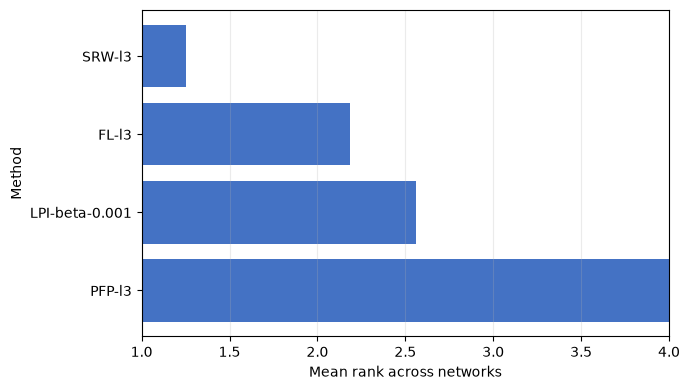

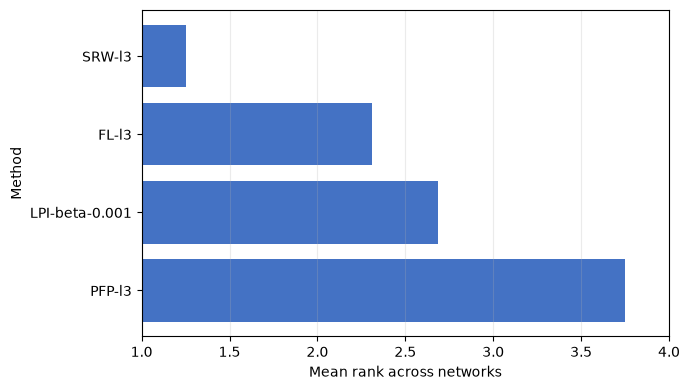

In [5]:
for metric in metrics:
    metric_ranks = (
        rank_table[
            rank_table[
                "metric"
            ]
            == metric
        ]
        .sort_values(
            [
                "mean_rank",
                "method",
            ],
            ascending=[
                False,
                True,
            ],
        )
    )

    figure, axis = plt.subplots(
        figsize=(
            7,
            4,
        )
    )

    axis.barh(
        metric_ranks[
            "method"
        ],
        metric_ranks[
            "mean_rank"
        ],
        color="#4472C4",
    )

    axis.set_xlabel(
        "Mean rank across networks"
    )

    axis.set_ylabel(
        "Method"
    )

    axis.set_xlim(
        1.0,
        float(
            len(method_ids)
        ),
    )

    axis.grid(
        axis="x",
        alpha=0.25,
    )

    figure.tight_layout()

    figure.savefig(
        figure_directory
        / (
            f"{metric}_"
            "confirmatory_mean_ranks.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )

    figure.savefig(
        figure_directory
        / (
            f"{metric}_"
            "confirmatory_mean_ranks.pdf"
        ),
        bbox_inches="tight",
    )

    plt.show()

In [6]:
pairwise_table = (
    pairwise.copy()
)

if not pairwise_table.empty:
    pairwise_table[
        "first_method_name"
    ] = pairwise_table[
        "first_method"
    ].map(
        method_names
    )

    pairwise_table[
        "second_method_name"
    ] = pairwise_table[
        "second_method"
    ].map(
        method_names
    )

pairwise_table[
    [
        "metric",
        "first_method_name",
        "second_method_name",
        "network_count",
        "p_value",
        "adjusted_p_value",
        "reject_null",
        "median_difference",
        "rank_biserial",
        "first_wins",
        "ties",
        "second_wins",
    ]
] if not pairwise_table.empty else pairwise_table

,metric,first_method_name,second_method_name,network_count,p_value,adjusted_p_value,reject_null,median_difference,rank_biserial,first_wins,ties,second_wins
0,average_precision,FL-l3,LPI-beta-0.001,8,0.250000,0.250000,False,0.000000,1.000000,3,5,0
1,average_precision,FL-l3,PFP-l3,8,0.007812,0.046875,True,0.005513,1.000000,8,0,0
2,average_precision,FL-l3,SRW-l3,8,0.054688,0.164062,False,-0.002064,-0.777778,1,0,7
3,average_precision,LPI-beta-0.001,PFP-l3,8,0.007812,0.046875,True,0.005480,1.000000,8,0,0
4,average_precision,LPI-beta-0.001,SRW-l3,8,0.054688,0.164062,False,-0.002097,-0.777778,1,0,7
5,average_precision,PFP-l3,SRW-l3,8,0.007812,0.046875,True,-0.006491,-1.000000,0,0,8
6,roc_auc,FL-l3,LPI-beta-0.001,8,0.250000,0.250000,False,0.000000,1.000000,3,5,0
7,roc_auc,FL-l3,PFP-l3,8,0.015625,0.078125,False,0.002574,0.944444,7,0,1
8,roc_auc,FL-l3,SRW-l3,8,0.054688,0.164062,False,-0.001635,-0.777778,1,0,7
9,roc_auc,LPI-beta-0.001,PFP-l3,8,0.015625,0.078125,False,0.002556,0.944444,7,0,1


In [7]:
network_metric_table = (
    network_metrics.copy()
)

network_metric_table[
    "method"
] = network_metric_table[
    "method_id"
].map(
    method_names
)

network_metric_table[
    [
        "network_id",
        "metric",
        "method",
        "value",
    ]
].sort_values(
    [
        "metric",
        "network_id",
        "method",
    ]
).reset_index(
    drop=True
)

,network_id,metric,method,value
0,ca_grqc,average_precision,FL-l3,0.982031
1,ca_grqc,average_precision,LPI-beta-0.001,0.982031
2,ca_grqc,average_precision,PFP-l3,0.981090
3,ca_grqc,average_precision,SRW-l3,0.983031
4,ca_hepth,average_precision,FL-l3,0.967846
...,...,...,...,...
59,power_grid,roc_auc,SRW-l3,0.771159
60,socfb_middlebury45,roc_auc,FL-l3,0.950325
61,socfb_middlebury45,roc_auc,LPI-beta-0.001,0.950232
62,socfb_middlebury45,roc_auc,PFP-l3,0.934823
